# 1-halo tSZ power spectrum: catalogue sum with the DEFAULT GNFW pressure profile

Companion to `14_catalogue_tsz_power_spectrum.ipynb`. There the per-cluster
amplitude was the **measured** `Y_5R500c`. Here the catalogue Poisson sum uses
the **default GNFW pressure profile** instead: each cluster's integrated Compton-Y
is *predicted* from its (M_500c, z) with the Arnaud-2010 GNFW model, exactly as in
`13_infer_B_from_Y5R500c.ipynb`, and combined with the same GNFW form factor. The
hydrostatic mass bias is fixed to the full-sky best fit **B = 1.1093** (from
`chains/mcmc_pureGNFW_fitB`), i.e. the profile sees the HSE mass M_500c / B.

The **white ell->0 limit is taken from the measured `Y_5R500c`** (dotted lines):
at ell->0 the form factor Ghat->1, so the plateau C_white = sum(Y_ang^2)/4pi depends
only on each cluster's *total* Compton-Y, not on the assumed shape. Using the
measured Y makes it the model-independent, empirical plateau. The gap between the
default-GNFW catalogue sum and this dotted measured-Y plateau is the amplitude
mismatch of the default A10 profile at this bias.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

from flamingo import paths
from flamingo.catalogue import load_catalogue, frame
from hmfast.halos.profiles.pressure import GNFWPressureProfile

ARCMIN_PER_RAD = 180.0 / np.pi * 60.0
h = frame._h

## Catalogue and the measured-Y white plateau

`Y_ang^meas = Y_5R500c / D_A^2` [sr] is the measured total Compton-Y per cluster;
its squared sum sets the empirical white plateau. We also load the NaMaster map
bandpowers (`data/nb09_tsz_map_ps.npz`).

In [2]:
df = load_catalogue(paths.HYDRO / 'catalogue' / 'halo_catalogue_M500c_5e13_zlt3_y0q_arnaudB1.csv')
df = df[(df['Y_5R500c_Mpc2'] > 0) & (df['M_500c_Msun'] > 0)
        & (df['R_500c_Mpc'] > 0) & np.isfinite(df['q'])]
z = df['z'].values
M = df['M_500c_Msun'].values                           # true M_500c
R = df['R_500c_Mpc'].values                            # proper Mpc
Yobs = df['Y_5R500c_Mpc2'].values                      # = D_A^2 Y_sph, proper Mpc^2 (MEASURED)
qv = df['q'].values
th500 = df['theta500_arcmin'].values / ARCMIN_PER_RAD  # proper, radians

Yang_meas = Yobs * (th500 / R) ** 2                    # measured Y_ang [sr] -> white plateau
print(f'clusters: {len(df)}')
print(f'measured white plateau  C_white = sum(Y_ang^2)/4pi = {np.sum(Yang_meas**2)/(4*np.pi):.3e} [sr]')

dat = np.load(paths.DATA / 'nb09_tsz_map_ps.npz')
ellb = dat['ellb']; dl_map = dat['dl_map']
Q_CUTS = [50, 20, 10, 5]
dl_cut_map = {qc: dat[f'dl_q{qc}'] for qc in Q_CUTS}
print('map bandpowers:', f'{ellb.min():.0f} -> {ellb.max():.0f}')

clusters: 1555542
measured white plateau  C_white = sum(Y_ang^2)/4pi = 2.943e-16 [sr]
map bandpowers: 16 -> 5956


## Default GNFW pressure profile: predicted amplitude + form factor

Predicted spherical Y from (M_500c, z) with the Arnaud-2010 GNFW model (B=1),
identical to nb13: Y = (sigma_T/m_e c^2) 4pi P0 I5 R500^3 P500. The shape (and the
form factor Ghat) use the same default `GNFWPressureProfile` parameters.

In [3]:
prof = GNFWPressureProfile(B=1.0)                      # default A10 GNFW (B=1)
P0, c500, al, be, ga = prof.P0, prof.c500, prof.alpha, prof.beta, prof.gamma
print(f'default GNFW: P0={P0}, c500={c500}, alpha={al}, beta={be}, gamma={ga}, B={prof.B}')

def p_shape(x):
    xc = c500 * np.maximum(x, 1e-12)
    return xc ** (-ga) * (1.0 + xc ** al) ** ((ga - be) / al)

I5 = quad(lambda x: p_shape(x) * x * x, 0.0, 5.0, limit=400)[0]

# physical constants (match hmfast pressure.py / nb13)
SIGMA_T = 6.6524587e-25; MEC2_EV = 510998.95; MPC_CM = 3.0856775814913673e24
RHO_C0 = 2.775e11 * h * h; ALPHA_P = 0.12

def R500_of_M(Mm, zz):
    return (3.0 * Mm / (4.0 * np.pi * 500.0 * RHO_C0 * frame.efunc(zz) ** 2)) ** (1.0 / 3.0)

def Y_A10_Mpc2(Mm, zz, B=1.0):
    Ezz = frame.efunc(zz); Mt = Mm / B
    R500_cm = R500_of_M(Mt, zz) * MPC_CM
    P500 = (1.65 * (h / 0.7) ** 2 * Ezz ** (8.0 / 3.0)
            * (Mt * h / (0.7 * 3e14)) ** (2.0 / 3.0 + ALPHA_P) * (0.7 / h) ** 1.5)
    return (SIGMA_T / MEC2_EV) * 4.0 * np.pi * P0 * P500 * R500_cm ** 3 * I5 / MPC_CM ** 2

# default-GNFW PREDICTED per-cluster amplitude (drives the catalogue sum curve).
# Bias fixed to the full-sky best fit B=1.1093 (chains/mcmc_pureGNFW_fitB): the
# A10 mass entering the profile is the HSE mass M/B, so Y scales as (M/B)^gamma_Y.
B_FIT = 1.1093
Y_pred = Y_A10_Mpc2(M, z, B_FIT)
Yang_pred = Y_pred * (th500 / R) ** 2
print(f'predicted (default GNFW, B={B_FIT}) white plateau = {np.sum(Yang_pred**2)/(4*np.pi):.3e} [sr]')
print(f'median Y_meas / Y_default(B={B_FIT}) = {np.median(Yobs / Y_pred):.4f}')

# GNFW form factor Ghat(u = l*theta500), normalised, default shape
u_tab = np.geomspace(1e-3, 400.0, 600)
G_tab = np.array([quad(lambda x: p_shape(x) * x * x * np.sinc(u * x / np.pi), 0, 5, limit=400)[0] / I5
                  for u in u_tab])
def Ghat(u):
    return np.interp(np.clip(u, u_tab[0], u_tab[-1]), u_tab, G_tab)
print(f'Ghat(1)={Ghat(1.0):.3f}  Ghat(3)={Ghat(3.0):.3f}  Ghat(6)={Ghat(6.0):.3f}')

default GNFW: P0=8.13, c500=1.156, alpha=1.062, beta=5.4807, gamma=0.3292, B=1.0


predicted (default GNFW, B=1.1093) white plateau = 2.368e-16 [sr]
median Y_meas / Y_default(B=1.1093) = 1.1836


Ghat(1)=0.733  Ghat(3)=0.294  Ghat(6)=0.094


## Catalogue sum (default GNFW) and measured-Y white plateau

Catalogue sum: C_ell = (1/4pi) sum_i Y_ang,pred_i^2 Ghat(l theta500_i)^2  (default GNFW).
White plateau (dotted): C_white = (1/4pi) sum_i Y_ang,meas_i^2  (MEASURED Y_5R500c).
Each q-cut sums the survivors q < q_cut; the map is masked for q > q_cut.

In [4]:
def to_dl(ell, cl): return ell * (ell + 1) * cl / (2 * np.pi)

def cl_pred(ell, mask=None):
    w2 = (Yang_pred if mask is None else Yang_pred[mask]) ** 2
    t = th500 if mask is None else th500[mask]
    return np.array([np.sum(w2 * Ghat(l * t) ** 2) / (4 * np.pi) for l in ell])

def c_white_meas(mask=None):                           # MEASURED-Y plateau
    w = Yang_meas if mask is None else Yang_meas[mask]
    return np.sum(w ** 2) / (4 * np.pi)

ell_fine = np.geomspace(5.0, 8000.0, 70)
sel = (ellb > 400) & (ellb < 6000)

dl_full = to_dl(ell_fine, cl_pred(ell_fine))
dl_full_b = to_dl(ellb, cl_pred(ellb))
cw_full = c_white_meas()
print(f'FULL SKY  median(default-GNFW cat-sum / map), 400<l<6000 = {np.median((dl_full_b/dl_map)[sel]):.3f}')

dl_cut_fine, dl_cut_b, cw_cut = {}, {}, {}
for qc in Q_CUTS:
    surv = qv < qc
    dl_cut_fine[qc] = to_dl(ell_fine, cl_pred(ell_fine, mask=surv))
    dl_cut_b[qc] = to_dl(ellb, cl_pred(ellb, mask=surv))
    cw_cut[qc] = c_white_meas(surv)
    print(f'q<{qc:<3d} ({int(surv.sum()):>7d} survivors)  '
          f'median(cat-sum / map) = {np.median((dl_cut_b[qc]/dl_cut_map[qc])[sel]):.3f}')

FULL SKY  median(default-GNFW cat-sum / map), 400<l<6000 = 0.958


q<50  (1555540 survivors)  median(cat-sum / map) = 0.958


q<20  (1555450 survivors)  median(cat-sum / map) = 0.957


q<10  (1555006 survivors)  median(cat-sum / map) = 0.944


q<5   (1553150 survivors)  median(cat-sum / map) = 0.919


## Figure

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb24_catalogue_tsz_ps_default_gnfw


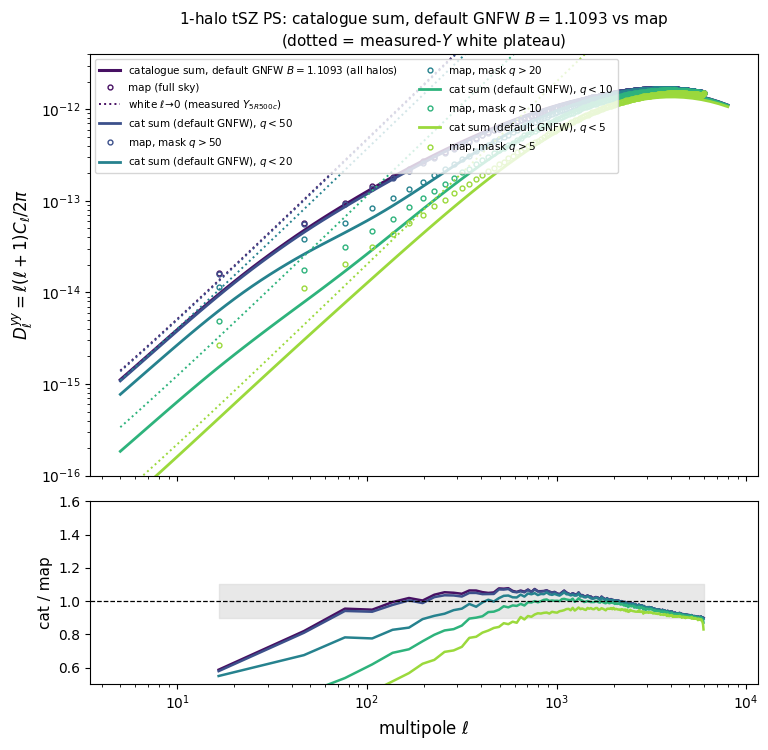

In [5]:
colors = plt.cm.viridis(np.linspace(0.04, 0.85, len(Q_CUTS) + 1))
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.8, 7.6), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1.3]})

ax.plot(ell_fine, dl_full, color=colors[0], lw=2.2, label=f'catalogue sum, default GNFW $B={B_FIT}$ (all halos)')
ax.plot(ellb, dl_map, 'o', color=colors[0], ms=3.5, mfc='none', label='map (full sky)')
ax.plot(ell_fine, to_dl(ell_fine, cw_full), ':', color=colors[0], lw=1.4,
        label=r'white $\ell\!\to\!0$ (measured $Y_{5R500c}$)')
axr.plot(ellb, dl_full_b / dl_map, color=colors[0], lw=1.8)

for i, qc in enumerate(Q_CUTS):
    c = colors[i + 1]
    ax.plot(ell_fine, dl_cut_fine[qc], color=c, lw=2.0, label=fr'cat sum (default GNFW), $q<{qc}$')
    ax.plot(ellb, dl_cut_map[qc], 'o', color=c, ms=3.5, mfc='none', label=fr'map, mask $q>{qc}$')
    ax.plot(ell_fine, to_dl(ell_fine, cw_cut[qc]), ':', color=c, lw=1.4)
    axr.plot(ellb, dl_cut_b[qc] / dl_cut_map[qc], color=c, lw=1.8)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_ylabel(r'$D_\ell^{yy}=\ell(\ell+1)C_\ell/2\pi$', fontsize=12)
ax.set_title(f'1-halo tSZ PS: catalogue sum, default GNFW $B={B_FIT}$ vs map\n'
             '(dotted = measured-$Y$ white plateau)', fontsize=11)
ax.legend(fontsize=7.5, ncol=2, loc='upper left'); ax.set_ylim(1e-16, 4e-12)
ax.tick_params(labelsize=10)

axr.axhline(1.0, color='k', lw=0.9, ls='--')
axr.fill_between([ellb.min(), ellb.max()], 0.9, 1.1, color='0.85', alpha=0.6)
axr.set_xlabel(r'multipole $\ell$', fontsize=12)
axr.set_ylabel('cat / map', fontsize=11); axr.set_ylim(0.5, 1.6); axr.tick_params(labelsize=10)
fig.tight_layout()

import os
OUT = '/scratch/scratch-lxu/flamingo_repo/figures/nb24_catalogue_tsz_ps_default_gnfw'
os.makedirs(OUT, exist_ok=True)
fig.savefig(os.path.join(OUT, 'nb24_cat_sum_default_gnfw.pdf'))
fig.savefig(os.path.join(OUT, 'nb24_cat_sum_default_gnfw.png'), dpi=300)
print('saved ->', OUT)
plt.show()

## Notes

- **Catalogue sum** uses the default GNFW pressure profile (bias B=1.1093) for
  *both* amplitude (predicted Y from M_500c, z) and shape (form factor Ghat).
  1-halo only.
- **White dotted lines** use the *measured* `Y_5R500c` and so mark the true,
  shape-independent ell->0 plateau, independent of the assumed B.
- Applying the full-sky best-fit bias B=1.1093 lowers the predicted Y by
  (1/B)^gamma_Y per cluster and brings the catalogue sum down close to the map,
  in contrast to the B=1 case which over-predicts by ~39%.
- The low-ell (l < 300) deficit vs the map is the omitted 2-halo term.